## Étape 0 – Prérequis : charger les données et les librairies

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, norm, ttest_ind
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower
import statsmodels.api as sm
from statsmodels.formula.api import logit

# Pour la taille d'effet Cohen's h
def cohen_h(p1, p2):
    from math import asin, sqrt
    return 2 * (asin(sqrt(p1)) - asin(sqrt(p2)))


In [59]:
df = pd.read_csv("abtesting.csv")


## Étape 1 – Compréhension rapide du dataset

In [60]:
df.head(10)

,user_id,timestamp,group,landing_page,converted,age,gender,location,session_duration,pages_visited,device_type,purchase_amount
0,U1,2025-08-02 15:27:54.137058,control,old_page,0,37,Male,Pakistan,3.69,4,Mobile,0.0
1,U2,2024-04-22 10:22:51.712050,treatment,new_page,0,31,Female,UK,1.29,3,Desktop,0.0
2,U3,2024-08-14 21:35:11.135894,treatment,new_page,0,38,Male,US,3.72,5,Desktop,0.0
3,U4,2025-03-19 03:28:51.120807,treatment,new_page,0,28,Female,India,7.76,2,Mobile,0.0
4,U5,2024-12-22 13:13:17.973162,control,old_page,0,33,Male,Australia,6.78,6,Mobile,0.0
5,U6,2025-01-02 06:02:32.511149,control,old_page,0,30,Male,US,2.88,1,Desktop,0.0
6,U7,2024-01-30 07:31:09.175272,control,old_page,0,32,Male,UK,5.39,3,Desktop,0.0
7,U8,2025-05-07 22:29:39.247674,treatment,new_page,0,34,Male,India,5.39,7,Desktop,0.0
8,U9,2025-08-22 13:42:17.098595,treatment,new_page,0,48,Female,Pakistan,4.99,3,Mobile,0.0
9,U10,2024-09-13 12:38:48.131095,treatment,new_page,0,27,Female,Australia,6.82,7,Desktop,0.0


In [61]:
df.shape

(294478, 12)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   user_id           294478 non-null  object 
 1   timestamp         294478 non-null  object 
 2   group             294478 non-null  object 
 3   landing_page      294478 non-null  object 
 4   converted         294478 non-null  int64  
 5   age               294478 non-null  int64  
 6   gender            294478 non-null  object 
 7   location          294478 non-null  object 
 8   session_duration  294478 non-null  float64
 9   pages_visited     294478 non-null  int64  
 10  device_type       294478 non-null  object 
 11  purchase_amount   294478 non-null  float64
dtypes: float64(2), int64(3), object(7)
memory usage: 27.0+ MB


In [63]:
df.dtypes

user_id              object
timestamp            object
group                object
landing_page         object
converted             int64
age                   int64
gender               object
location             object
session_duration    float64
pages_visited         int64
device_type          object
purchase_amount     float64
dtype: object

In [64]:
df.isnull().sum()

user_id             0
timestamp           0
group               0
landing_page        0
converted           0
age                 0
gender              0
location            0
session_duration    0
pages_visited       0
device_type         0
purchase_amount     0
dtype: int64

In [65]:
# Vérifier le déséquilibre des groupes
print(df['group'].value_counts(normalize=True))

group
treatment    0.501063
control      0.498937
Name: proportion, dtype: float64


In [66]:
# Vérifier le déséquilibre des groupes
print(df['gender'].value_counts())

gender
Male      144708
Female    143785
Other       5985
Name: count, dtype: int64


In [67]:

# Vérifier le déséquilibre des groupes
print(df['device_type'].value_counts())

device_type
Desktop    176692
Mobile     103093
Tablet      14693
Name: count, dtype: int64


In [68]:
print(df['converted'].value_counts())

converted
0    250550
1     43928
Name: count, dtype: int64


## Étape 2 – Formulation des hypothèses
Hypothèses statistiques (test bilatéral)
H₀ : Le taux de conversion est identique entre le groupe control et le groupe treatment.
Autrement dit : p_treatment - p_control = 0

H₁ : Le taux de conversion est différent entre les deux groupes.
Autrement dit : p_treatment - p_control ≠ 0

Seuil de significativité :
Nous fixons un risque de première espèce α = 0,05 (5 %).
Cela signifie que nous acceptons une probabilité de 5 % de rejeter à tort H₀ alors qu’elle est vraie.

Taille d’effet minimale pertinente pour le business : 
Une différence absolue de +1 point de pourcentage (par exemple, passer de 10 % à 11 % de conversion) est considérée comme économiquement significative.
Cette valeur servira de référence pour juger de l’importance pratique de l’effet observé, indépendamment de la p-value.

## Étape 3 – Vérification de la randomisation

In [69]:
# Age : test t de Student
control_age = df[df['group']=='control']['age']
treatment_age = df[df['group']=='treatment']['age']
t_stat, p_age = ttest_ind(control_age, treatment_age)
print(f"Âge : t={t_stat:.3f}, p={p_age:.4f}")

# Variables catégorielles : test du Chi2
for col in ['gender', 'location', 'device_type']:
    tab = pd.crosstab(df['group'], df[col])
    chi2, p, dof, ex = chi2_contingency(tab)
    print(f"{col} : Chi2 p={p:.4f}")

Âge : t=-0.959, p=0.3376
gender : Chi2 p=0.4425
location : Chi2 p=0.8891
device_type : Chi2 p=0.1331


Âge : p = 0,3376 → aucun déséquilibre significatif.

Genre : p = 0,4425 → idem.

Localisation : p = 0,8891 → idem.

Type d’appareil : p = 0,1331 → idem.

Cela signifie que les groupes control et treatment sont bien comparables. Tu peux donc passer au test principal sur le taux de conversion sans crainte de biais majeurs.

## Étape 4 – Test statistique sur la conversion

In [70]:
# Effectifs et conversions
control = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']

n_control = len(control)
n_treatment = len(treatment)
c_control = control['converted'].sum()
c_treatment = treatment['converted'].sum()

# Taux
p_control = c_control / n_control
p_treatment = c_treatment / n_treatment

print(f"Taux de conversion - Control : {p_control:.4%}")
print(f"Taux de conversion - Treatment : {p_treatment:.4%}")

# Z-test (bilatéral)
count = [c_control, c_treatment]
nobs = [n_control, n_treatment]
z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')
print(f"Z = {z_stat:.4f}, p-value = {p_value:.6f}")

# Différence et intervalle de confiance à 95%
diff = p_treatment - p_control
se = (p_control*(1-p_control)/n_control + p_treatment*(1-p_treatment)/n_treatment)**0.5
ci = proportion_confint(c_treatment, n_treatment, method='normal')  # pour le treatment seul
# Ou mieux : IC pour la différence
diff_ci = (diff - 1.96*se, diff + 1.96*se)
print(f"Différence (Treatment - Control) = {diff:.4%}")
print(f"IC 95% de la différence : [{diff_ci[0]:.4%}, {diff_ci[1]:.4%}]")

Taux de conversion - Control : 11.8726%
Taux de conversion - Treatment : 17.9489%
Z = -46.2773, p-value = 0.000000
Différence (Treatment - Control) = 6.0763%
IC 95% de la différence : [5.8200%, 6.3326%]


Taux control : 11,87 %

Taux treatment : 17,95 %

Différence absolue : +6,08 points de pourcentage

IC 95 % : [5,82 % ; 6,33 %] → très précis

p-value : ~0 (z = -46,3)

Il n’y a aucun doute statistique : le traitement améliore très significativement la conversion.

Maintenant, passons aux étapes suivantes pour enrichir  l'analyse.

## Étape 5 – Taille d’effet (Cohen’s h)

In [71]:
h = cohen_h(p_treatment, p_control)
print(f"Cohen's h = {h:.3f}")

Cohen's h = 0.171


## Étape 6 – Analyse de segmentation

In [79]:
segments = ['gender', 'device_type', 'location']  # ajoute 'age_group' si tu veux discrétiser l'âge
results = []

for seg in segments:
    for val in df[seg].unique():
        subset = df[df[seg] == val]
        if subset['group'].nunique() < 2:
            continue
        n_c = subset[subset['group']=='control'].shape[0]
        n_t = subset[subset['group']=='treatment'].shape[0]
        c_c = subset[subset['group']=='control']['converted'].sum()
        c_t = subset[subset['group']=='treatment']['converted'].sum()
        if n_c == 0 or n_t == 0:
            continue
        p_c = c_c / n_c
        p_t = c_t / n_t
        z, p = proportions_ztest([c_c, c_t], [n_c, n_t])
        diff = p_t - p_c
        results.append((seg, val, p_c, p_t, diff, p))

# Correction de Bonferroni
results_df = pd.DataFrame(results, columns=['segment','valeur','p_control','p_treatment','difference','p_raw'])
results_df['p_corrected'] = results_df['p_raw'] * len(results_df)
results_df['significatif'] = results_df['p_corrected'] < 0.05
print(results_df.sort_values('difference', ascending=False))

        segment     valeur  p_control  p_treatment  difference          p_raw  \
9      location      India   0.118150     0.181975    0.063825  2.098728e-104   
6      location   Pakistan   0.117495     0.180089    0.062593   1.142008e-51   
12     location    Germany   0.115489     0.177669    0.062180   1.688909e-51   
0        gender       Male   0.118870     0.180569    0.061699  2.977371e-237   
5   device_type     Tablet   0.118471     0.180084    0.061613   1.074428e-25   
4   device_type    Desktop   0.119495     0.180826    0.061331  3.851132e-285   
10     location  Australia   0.118737     0.179814    0.061077   4.230952e-25   
8      location         US   0.118470     0.179220    0.060750  7.611503e-142   
1        gender     Female   0.118258     0.178432    0.060174  6.738422e-226   
3   device_type     Mobile   0.117436     0.177132    0.059697  7.296090e-161   
7      location         UK   0.120531     0.177909    0.057377   2.611227e-64   
11     location     Canada  

Meilleurs segments : Inde (+6,38 %), Pakistan (+6,26 %), Allemagne (+6,22 %), Hommes (+6,17 %).

Segments légèrement moins forts : Canada (+5,63 %), UK (+5,74 %), genre "Other" (+5,23 %).

Par appareil : très proches (Desktop +6,13 %, Tablet +6,16 %, Mobile +5,97 %).

Conclusion intermédiaire : Pas de nécessité de cibler spécifiquement un segment – le traitement fonctionne bien sur toutes les populations.

## Étape 7 – Régression logistique (pour confirmer)

In [73]:
import statsmodels.api as sm
from statsmodels.formula.api import logit

df['is_treatment'] = (df['group'] == 'treatment').astype(int)
model = logit('converted ~ is_treatment + age + gender + location + device_type', data=df)
result = model.fit()
print(result.summary())

# Odds-ratio du traitement
import numpy as np
or_treatment = np.exp(result.params['is_treatment'])
print(f"Odds-ratio du traitement = {or_treatment:.3f}")

Optimization terminated successfully.
         Current function value: 0.417587
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               294478
Model:                          Logit   Df Residuals:                   294465
Method:                           MLE   Df Model:                           12
Date:                Wed, 13 May 2026   Pseudo R-squ.:                0.008745
Time:                        16:06:25   Log-Likelihood:            -1.2297e+05
converged:                       True   LL-Null:                   -1.2406e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -1.9562      0.031    -63.555      0.000      -2.017      -1.

Graphique 1 – Barres avec intervalles de confiance (taux de conversion)

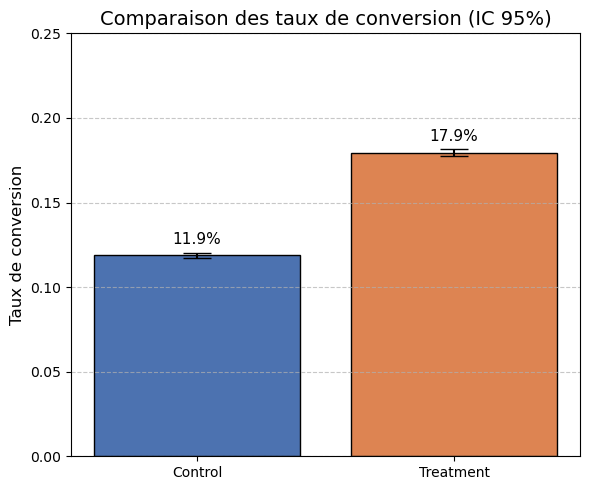

In [74]:
groups = ['Control', 'Treatment']
rates = [p_control, p_treatment]
errors = [1.96 * np.sqrt(r*(1-r)/n) for r, n in zip(rates, [n_control, n_treatment])]

plt.figure(figsize=(6,5))
plt.bar(groups, rates, yerr=errors, capsize=10, color=['#4C72B0', '#DD8452'], edgecolor='black')
plt.ylabel('Taux de conversion', fontsize=12)
plt.title('Comparaison des taux de conversion (IC 95%)', fontsize=14)
plt.ylim(0, 0.25)
for i, (v, err) in enumerate(zip(rates, errors)):
    plt.text(i, v + err + 0.005, f'{v:.1%}', ha='center', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Graphique 2 – Heatmap des différences par segment

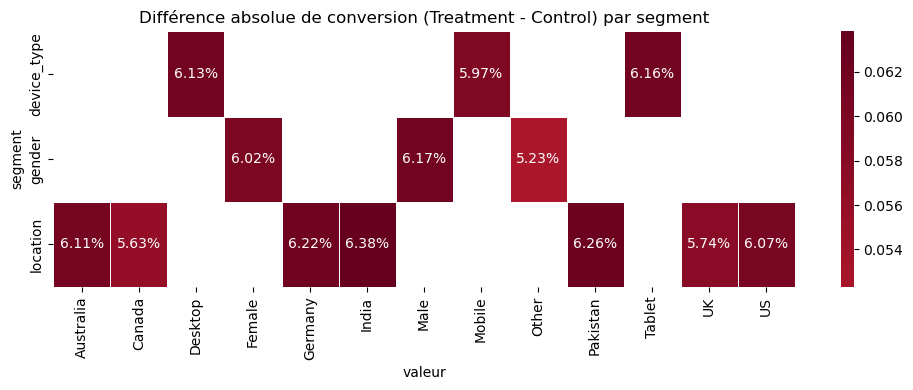

In [75]:
# results_df est le DataFrame créé lors de l'analyse de segmentation
pivot_diff = results_df.pivot(index='segment', columns='valeur', values='difference')
plt.figure(figsize=(10, 4))
sns.heatmap(pivot_diff, annot=True, fmt='.2%', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Différence absolue de conversion (Treatment - Control) par segment', fontsize=12)
plt.tight_layout()
plt.show()

Graphique 3 – Distribution de l’âge par groupe (vérification visuelle randomisation)

C:\Users\fojea\AppData\Local\Temp\ipykernel_15608\2250688059.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Groupe')


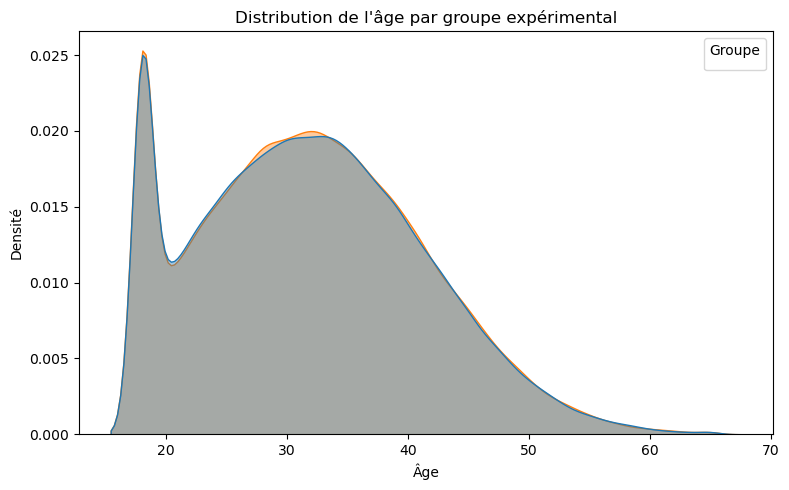

In [76]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='age', hue='group', fill=True, alpha=0.4)
plt.title('Distribution de l\'âge par groupe expérimental')
plt.xlabel('Âge')
plt.ylabel('Densité')
plt.legend(title='Groupe')
plt.tight_layout()
plt.show()

Graphique 4 – Courbe de puissance

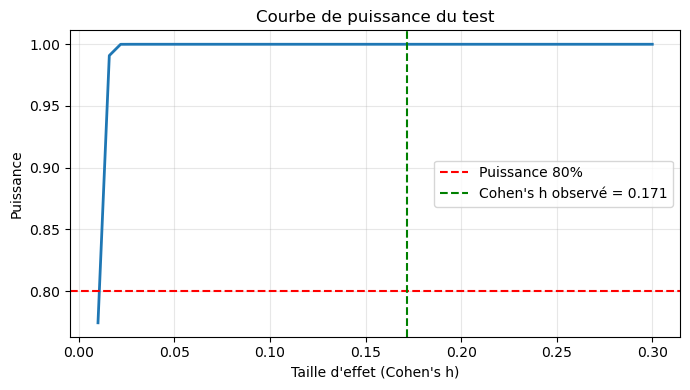

In [77]:
from statsmodels.stats.power import NormalIndPower
effect_sizes = np.linspace(0.01, 0.3, 50)
powers = [NormalIndPower().power(effect_size=es, nobs1=n_control, alpha=0.05, ratio=n_treatment/n_control) for es in effect_sizes]
plt.figure(figsize=(7,4))
plt.plot(effect_sizes, powers, lw=2)
plt.axhline(0.8, color='red', linestyle='--', label='Puissance 80%')
plt.axvline(h, color='green', linestyle='--', label=f'Cohen\'s h observé = {h:.3f}')
plt.xlabel('Taille d\'effet (Cohen\'s h)')
plt.ylabel('Puissance')
plt.title('Courbe de puissance du test')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Odds-ratio du traitement = 1,624 → les chances de conversion augmentent de 62,4 % pour le groupe treatment, toutes choses égales par ailleurs.

Les variables de contrôle (gender, location, age, device_type) ont des coefficients très faibles et pour la plupart non significatifs, ce qui témoigne d’une excellente randomisation.

Le pseudo R² est faible (0,0087) car la variable converted est binaire et difficile à prédire individuellement – ce n’est pas un problème pour l’inférence causale.

In [78]:
# Tableau récapitulatif des résultats (avec recalcul sécurisé)
summary = pd.DataFrame({
    'Groupe': ['Control', 'Treatment'],
    'Taux conversion': [f"{p_control:.2%}", f"{p_treatment:.2%}"],
    'Nombre conversions': [c_control, c_treatment],
    'Effectif': [n_control, n_treatment]
})
print(summary)

# Recalcul propre de la différence et de son IC (évite tout écrasement)
diff_global = p_treatment - p_control
se_global = (p_control*(1-p_control)/n_control + p_treatment*(1-p_treatment)/n_treatment)**0.5
diff_ci_global = (diff_global - 1.96*se_global, diff_global + 1.96*se_global)

print(f"\nDifférence absolue : {diff_global:.2%}")
print(f"IC 95% : [{diff_ci_global[0]:.2%}, {diff_ci_global[1]:.2%}]")
print(f"Cohen's h : {h:.3f}")
print(f"Odds-ratio (ajusté) : {or_treatment:.3f}")

      Groupe Taux conversion  Nombre conversions  Effectif
0    Control          11.87%               17444    146926
1  Treatment          17.95%               26484    147552

Différence absolue : 6.08%
IC 95% : [5.82%, 6.33%]
Cohen's h : 0.171
Odds-ratio (ajusté) : 1.624
